# Bike Rental Demand Prediction

## 1. Load & Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [3]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instant     17379 non-null  int64
 1   dteday      17379 non-null  str  
 2   season      17379 non-null  str  
 3   yr          17379 non-null  str  
 4   mnth        17379 non-null  str  
 5   hr          17379 non-null  int64
 6   holiday     17379 non-null  str  
 7   weekday     17379 non-null  int64
 8   workingday  17379 non-null  str  
 9   weathersit  17379 non-null  str  
 10  temp        17379 non-null  str  
 11  atemp       17379 non-null  str  
 12  hum         17379 non-null  str  
 13  windspeed   17379 non-null  str  
 14  casual      17379 non-null  str  
 15  registered  17379 non-null  str  
 16  cnt         17379 non-null  int64
dtypes: int64(4), str(13)
memory usage: 2.3 MB


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379,17379.000000,17379,17379.000000,17379,17379,17379,17379,17379,17379,17379,17379,17379.000000
unique,NaN,731,5,3,13,NaN,3,NaN,3,5,51,66,90,31,323,777,NaN
top,NaN,01-01-2011,fall,2012,5,NaN,No,NaN,Working Day,Clear,0.62,0.6212,0.88,0,0,4,NaN
freq,NaN,24,4496,8734,1488,NaN,16878,NaN,11862,11412,726,988,657,2180,1581,307,NaN
mean,8690.0000,NaN,NaN,NaN,NaN,11.546752,NaN,3.003683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.463088
std,5017.0295,NaN,NaN,NaN,NaN,6.914405,NaN,2.005771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,181.387599
min,1.0000,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,4345.5000,NaN,NaN,NaN,NaN,6.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000
50%,8690.0000,NaN,NaN,NaN,NaN,12.000000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142.000000
75%,13034.5000,NaN,NaN,NaN,NaN,18.000000,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281.000000


In [4]:
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')

categorical_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

season: 5 unique values
yr: 3 unique values
mnth: 13 unique values
hr: 24 unique values
holiday: 3 unique values
weekday: 7 unique values
workingday: 3 unique values
weathersit: 5 unique values


## 2. Data Cleaning

In [5]:
# Raw data uses '?' as a missing-value placeholder; convert to real NaN,
# then coerce the numeric columns (some are stored as strings due to the '?' values)
df.replace('?', pd.NA, inplace=True)

numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.isnull().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [6]:
# Impute numeric columns with median (robust to skew/outliers)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical columns with mode
categorical_impute_cols = ['season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit']
for col in categorical_impute_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.shape

Remaining missing values: 0
Duplicate rows: 0


(17379, 17)

## 3. Outlier Detection

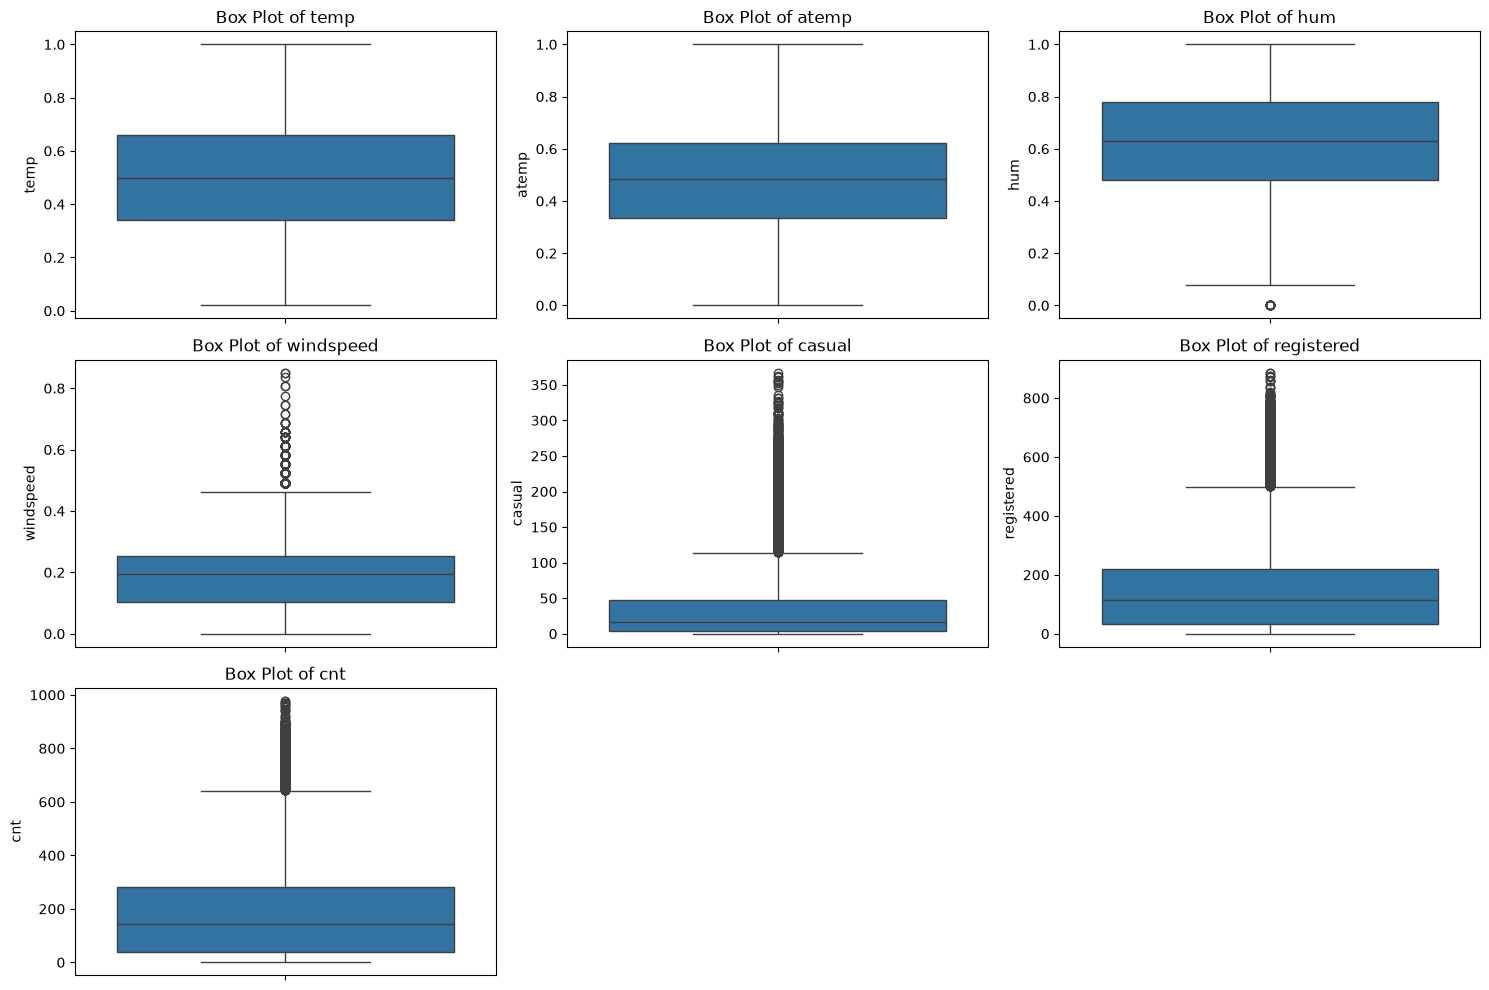

In [7]:
outlier_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

## 4. Time Series Trends

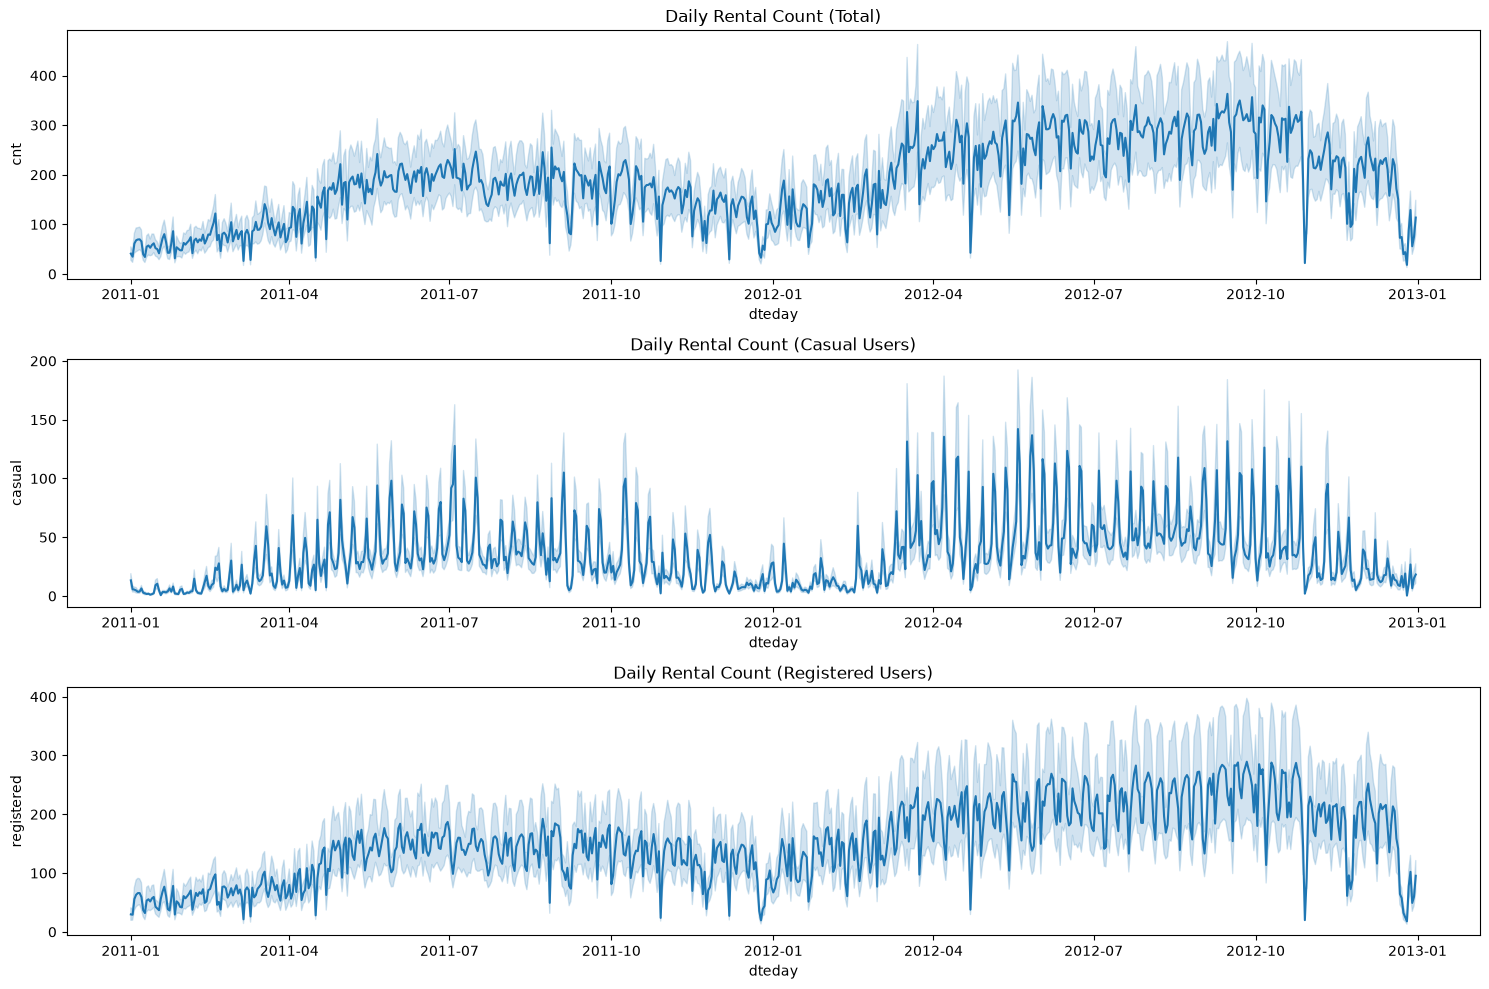

In [8]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
sns.lineplot(x=df['dteday'], y=df['cnt'])
plt.title('Daily Rental Count (Total)')

plt.subplot(3, 1, 2)
sns.lineplot(x=df['dteday'], y=df['casual'])
plt.title('Daily Rental Count (Casual Users)')

plt.subplot(3, 1, 3)
sns.lineplot(x=df['dteday'], y=df['registered'])
plt.title('Daily Rental Count (Registered Users)')

plt.tight_layout()
plt.show()

## 5. Rentals vs. Weather Features

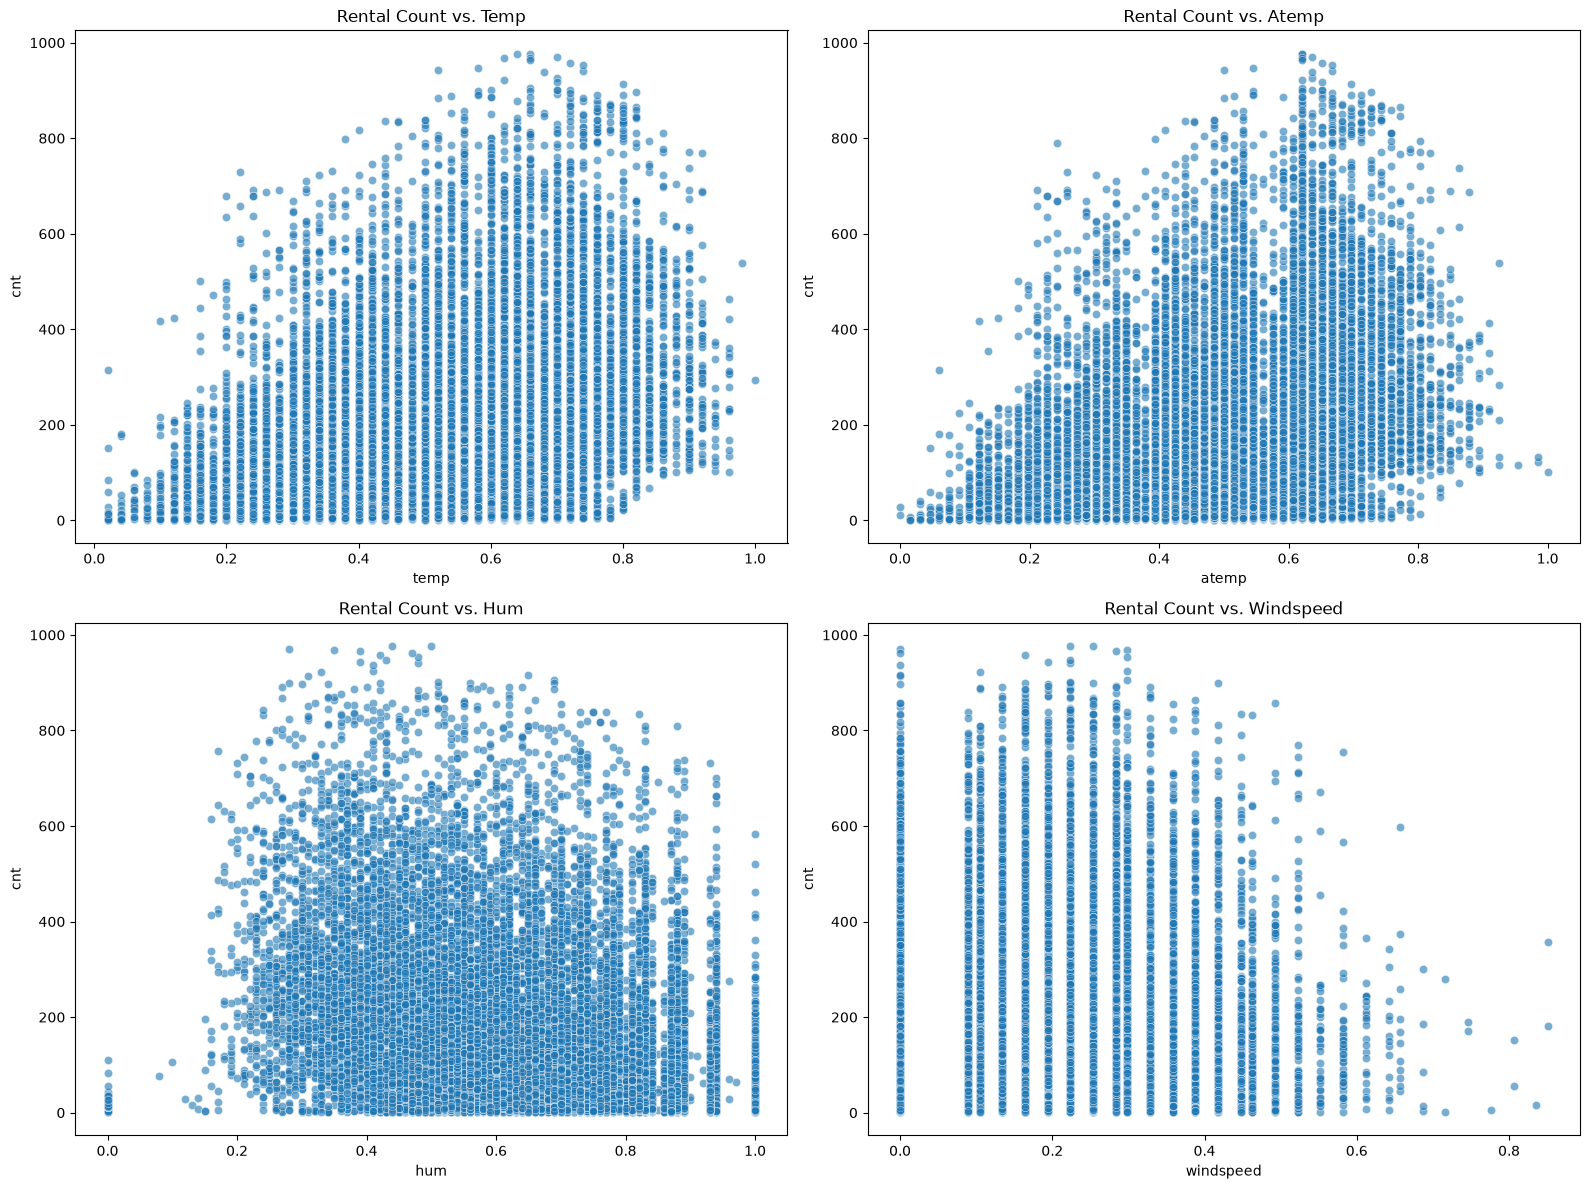

In [9]:
weather_cols = ['temp', 'atemp', 'hum', 'windspeed']

plt.figure(figsize=(16, 12))
for i, col in enumerate(weather_cols):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['cnt'], alpha=0.6)
    plt.title(f'Rental Count vs. {col.capitalize()}')
plt.tight_layout()
plt.show()

## 6. Average Rentals by Category

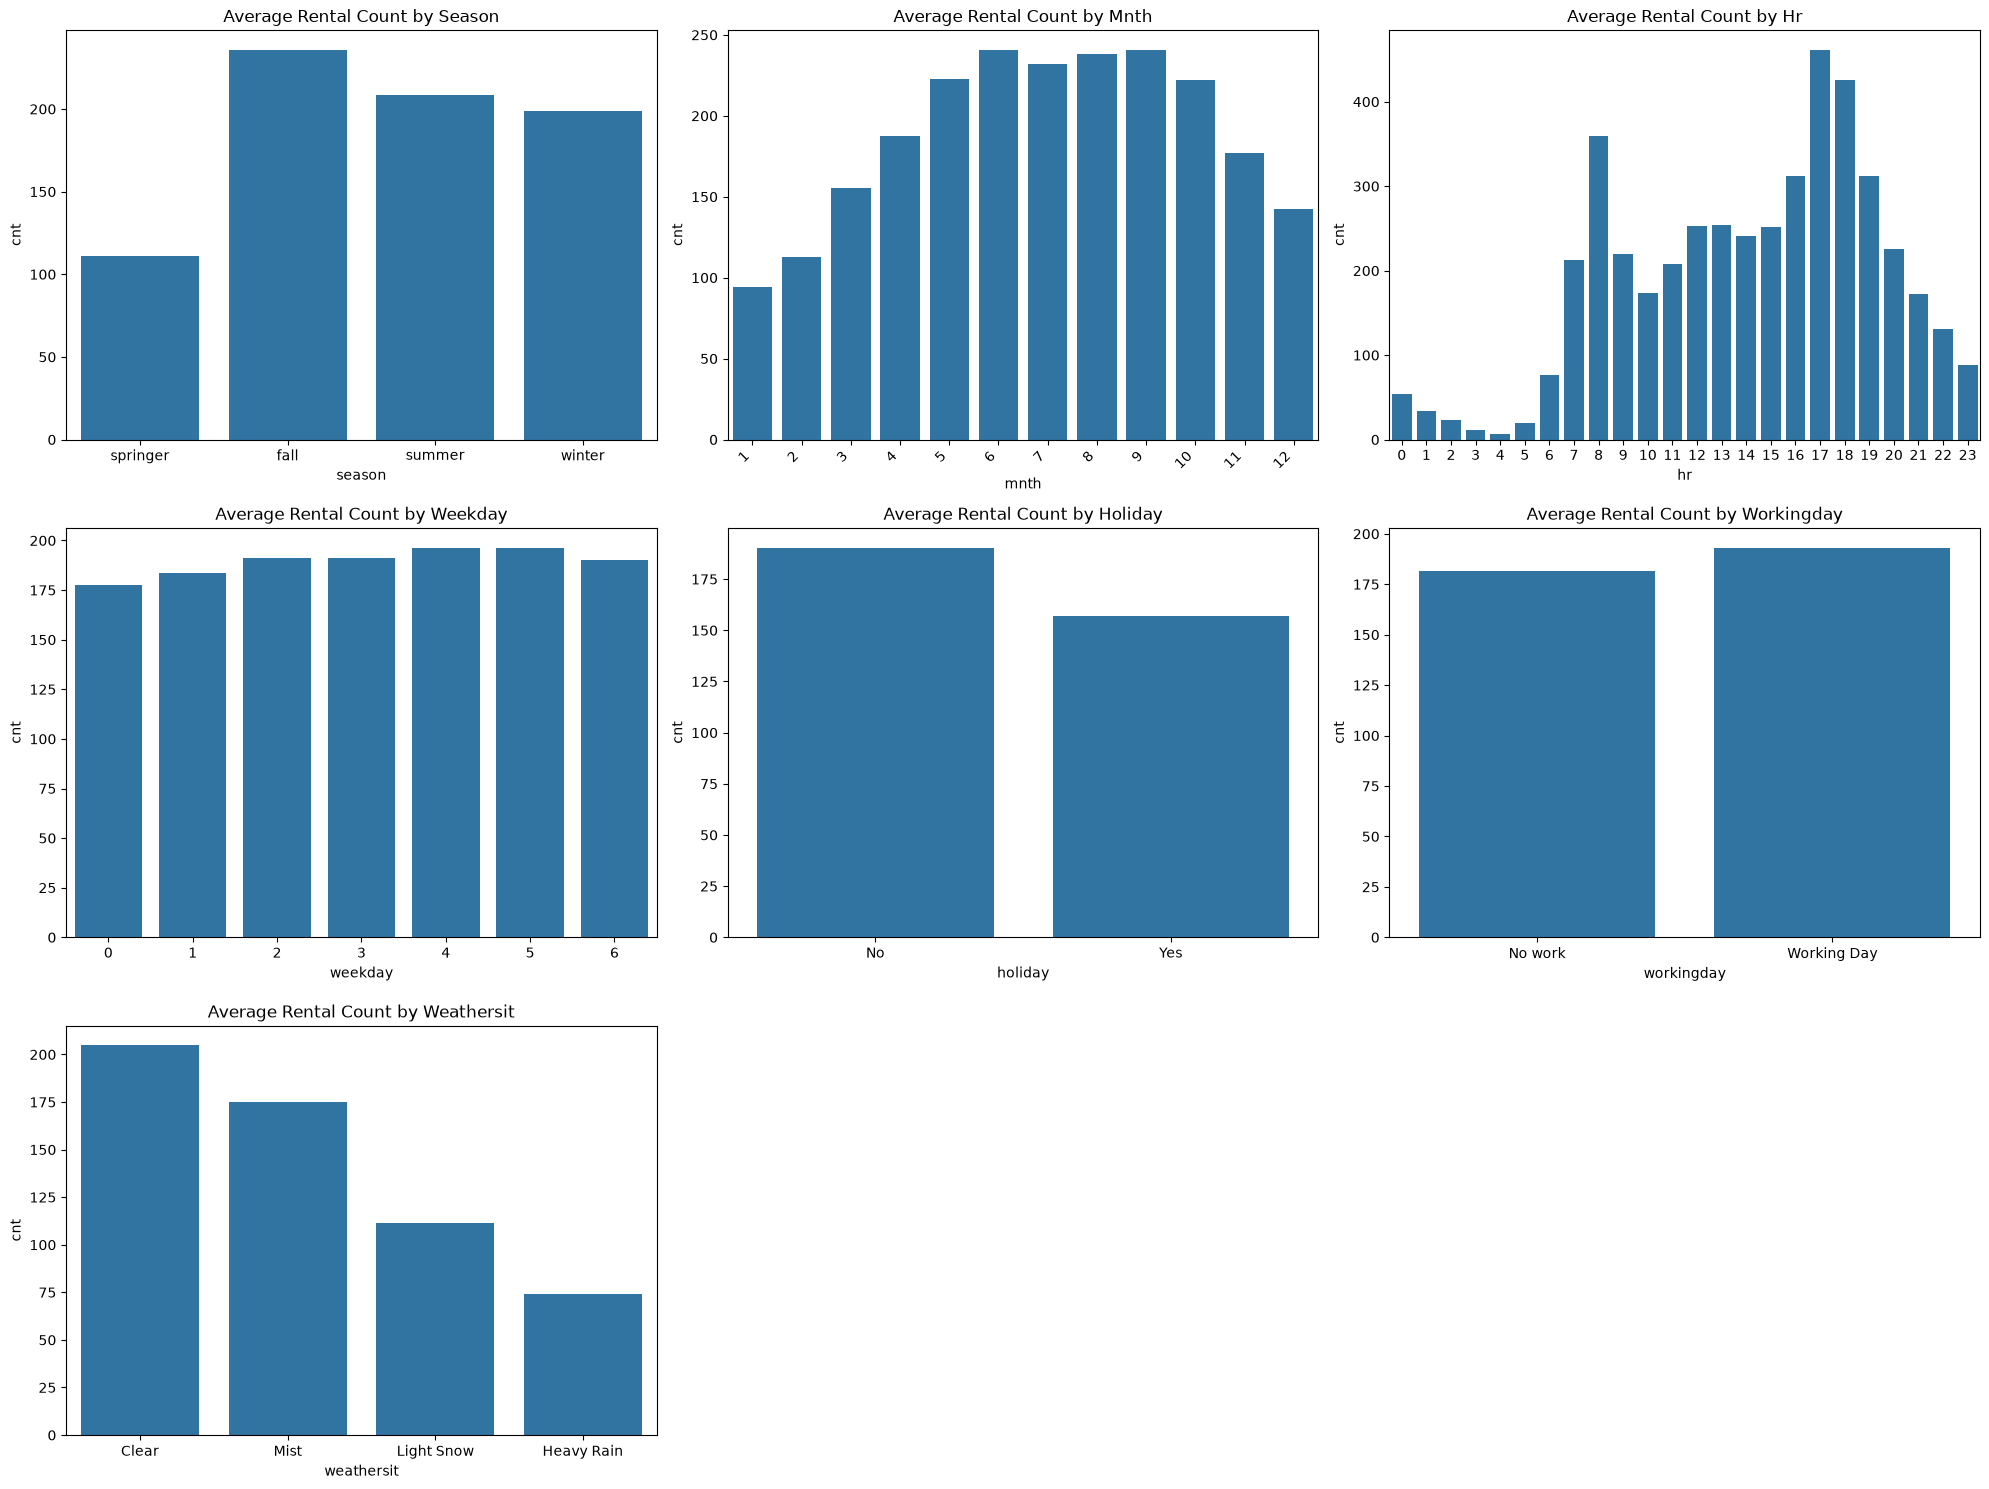

In [10]:
category_cols = ['season', 'mnth', 'hr', 'weekday', 'holiday', 'workingday', 'weathersit']

plt.figure(figsize=(20, 15))
for i, col in enumerate(category_cols):
    plt.subplot(3, 3, i + 1)
    sns.barplot(x=df[col], y=df['cnt'], estimator=np.mean, errorbar=None)
    plt.title(f'Average Rental Count by {col.capitalize()}')
    if col == 'mnth':
        plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

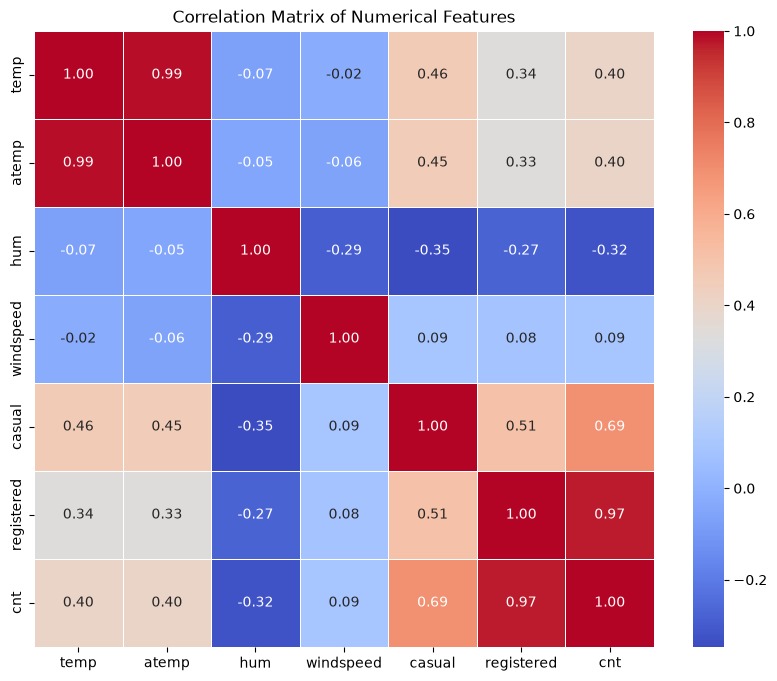

In [11]:
corr_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Note:** `casual` and `registered` are almost perfectly correlated with `cnt` because
`cnt = casual + registered` by definition. They're useful here for understanding user
behavior, but they **cannot** be used as model features — at prediction time you're
trying to forecast `cnt` itself, so its own components aren't available as inputs.

## 8. Feature Engineering

In [12]:
df['day_of_week'] = df['dteday'].dt.dayofweek
df['day_of_year'] = df['dteday'].dt.dayofyear
df['week_of_year'] = df['dteday'].dt.isocalendar().week.astype(int)

categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_features:
    df[col] = df[col].astype('category')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,day_of_week,day_of_year,week_of_year
0,1,2011-01-01,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0.0,3.0,13.0,16,5,1,52
1,2,2011-01-01,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.80,0.0,8.0,32.0,40,5,1,52
2,3,2011-01-01,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,0.63,0.0,5.0,27.0,32,5,1,52
3,4,2011-01-01,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0.0,3.0,10.0,13,5,1,52
4,5,2011-01-01,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0.0,0.0,1.0,1,5,1,52


## 9. Prepare Modeling Dataset

Columns dropped before modeling, and why:
- `instant`: a row index, not predictive
- `dteday`: raw date string — already represented numerically via `day_of_week`, `day_of_year`, `week_of_year`
- `casual`, `registered`: components of the target `cnt` — including them causes target leakage

No scaling is applied: Decision Tree and Random Forest split on thresholds rather than
distances/gradients, so they're scale-invariant.

In [13]:
model_df = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])
model_df = pd.get_dummies(model_df, drop_first=True)

X = model_df.drop(columns=['cnt'])
y = model_df['cnt']

X.shape, y.shape

((17379, 56), (17379,))

In [16]:
!pip install scikit-learn
import sys
!{sys.executable} -m pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 4.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.3 MB 4.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 4.0 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.3 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 4.0 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.8 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 3.8 MB/s eta 0:00:01
   ------------------------------------

((13903, 56), (3476, 56))

## 10. Decision Tree Regressor

A simple baseline model that learns decision rules from the data. Captures non-linear relationships but is prone to overfitting.

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_pred

array([360.,  33.,  10., ...,  61., 479., 214.], shape=(3476,))

## 11. Random Forest Regressor

An ensemble of decision trees that averages out individual trees' overfitting, generally improving generalization over a single tree.

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred

array([415.24, 111.23,  14.11, ...,  72.29, 279.72, 221.72], shape=(3476,))

## 12. Hyperparameter Tuning (GridSearchCV)

In [19]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_best_model = rf_grid.best_estimator_
rf_best_pred = rf_best_model.predict(X_test)
rf_grid.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

## 13. Model Evaluation

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2 Score": r2_score(y_true, y_pred)
    }


In [21]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Tuned Random Forest'],
    **{
        metric: [
            evaluate_model(y_test, dt_pred)[metric],
            evaluate_model(y_test, rf_pred)[metric],
            evaluate_model(y_test, rf_best_pred)[metric],
        ]
        for metric in ["MAE", "RMSE", "R2 Score"]
    }
})
results

,Model,MAE,RMSE,R2 Score
0,Decision Tree,43.202244,71.608273,0.838065
1,Random Forest,31.607586,50.103314,0.920723
2,Tuned Random Forest,31.366148,49.614305,0.922263


## 14. Conclusion

The Tuned Random Forest Regressor gives the best performance among the models tested,
with the lowest MAE/RMSE and the highest R² on the held-out test set. It is selected as
the final model for predicting bike rental demand. Feature importances and further tuning
(e.g. Gradient Boosting / XGBoost) are natural next steps before production deployment.